In [13]:
using GLPK, JuMP, Plots

model = Model(GLPK.Optimizer)

# alpha = 1.0; beta = 0.0   # only cost
alpha = 0.5; beta = 0.5   # balanced
# alpha = 0.2; beta = 0.8   # CO2-focused

T = 10      # Time
N = 20     # Anzahl Zeiteinheiten
M = 3
# 1 = Wärmepumpe        heat pump
# 2 = Biomassekessel    biomass boiler
# 3 = Gaskessel         gas boiler

# je Heizquelle
c = [25, 35, 80]         # COST              - €/MWh
s = [30, 40, 200]        # SUSTAINABILITY    - kg_CO2/MWh

m = [150, 150, 150]     # max. MW
# je Zeitpunkt      
"""Demand darf 370 nicht überschreiten"""

d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190]   # MW 
# Steigung - Steuerungsspontanität
k = [60,30,100]

@variable(model, x[1:M,1:N] >= 0)

# KOSTEN minimieren
@objective( model, Min, alpha * sum( sum(x[j,i]*c[j] for i=1:N) for j=1:M) + 
                        beta * sum( sum(x[j,i]*s[j] for i=1:N) for j=1:M))

# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model, [j=1:M,i=1:N], x[j,i] <= m[j])
# DEMAND muss erfüllt sein      -    für alle Zeitpunkte i
@constraint(model, [i=1:N],   sum( x[j,i] for j=1:M) >= d[i]    )

# Steuerungsspontanität
# increase
@constraint(model, [j=1:M, i=2:N],
    x[j,i] - x[j,i-1] <= k[j])
# decrease
@constraint(model, [j=1:M, i=2:N],
    x[j,i-1] - x[j,i] <= k[j])

optimize!(model)

# println("Solver status: ", termination_status(model))
# println("Solution status: ", primal_status(model))
## Printing the solution
println("Objective value = ", objective_value(model)) 

for j=1:M
    for i=1:N
        print(value(x[j,i]),"\t")
    end
    println(".")
end

cost = 0
CO2 = 0

for j=1:M
    for i=1:N
        cost += value(x[j,i])*c[j]
        CO2 += value(x[j,i])*s[j]
    end
end
println("Cost in €: ",cost)
println("CO2 in Kg: ", CO2)

Objective value = 207900.0
150.0	90.0	140.0	100.0	150.0	110.0	150.0	90.0	150.0	90.0	90.0	140.0	90.0	150.0	150.0	150.0	140.0	130.0	150.0	110.0	.
150.0	120.0	90.0	120.0	150.0	120.0	90.0	120.0	150.0	120.0	90.0	60.0	90.0	120.0	150.0	130.0	100.0	80.0	110.0	80.0	.
70.0	0.0	0.0	50.0	150.0	50.0	0.0	0.0	70.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	.
Cost in €: 172600.0
CO2 in Kg: 243200.0


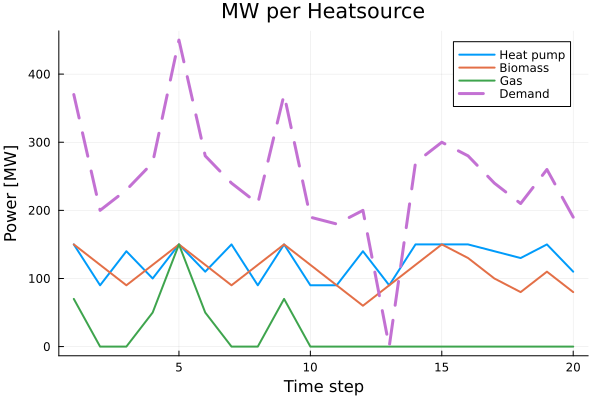

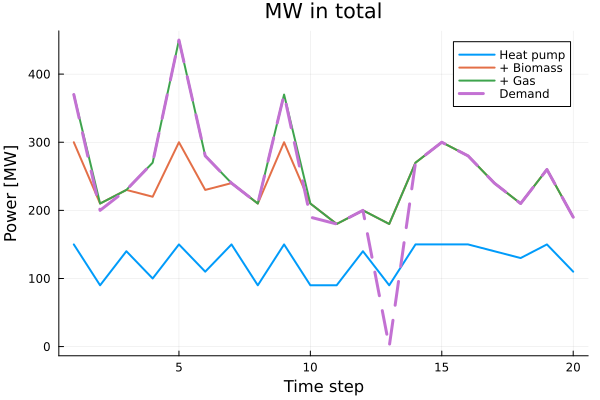

In [14]:
p = plot( 1:N, [value.(x[j,:]) for j in 1:3], labels=["Heat pump" "Biomass" "Gas"], xlabel="Time step", ylabel="Power [MW]", lw=2 , title="MW per Heatsource")
plot!(p, 1:N, d, label="Demand", lw=3, linestyle=:dash )
display(p)

x_result = value.(x)

hp  = x_result[1,:]
bio = hp .+ x_result[2,:]
gas = bio .+ x_result[3,:]

p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total")
plot!(p1, 1:N, bio, label="+ Biomass", lw=2)
plot!(p1, 1:N, gas, label="+ Gas", lw=2)
plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash)

xlabel!(p1, "Time step")
ylabel!(p1, "Power [MW]")

display(p1)
